# EDA & Evaluation - Continuous Sign Language Translation

Notebook này tổng hợp quá trình khám phá dữ liệu, phân tích input, theo dõi các thí nghiệm huấn luyện và đánh giá mô hình Continuous Sign Language Translation.

## Nội dung

1. Khám phá và thống kê dataset
2. Phân tích độ dài câu và phân bố dữ liệu
3. Mô tả preprocessing và input representation
4. Training Experiments (setup, bảng thí nghiệm, phân tích quá trình huấn luyện)
5. Evaluation (BLEU, WER, Semantic Similarity, phân tích định tính)
6. Tổng kết kết quả và hướng cải thiện

## 1. Model

Mô hình sử dụng:
- Pose + Left Hand + Right Hand keypoints
- Face landmarks được loại bỏ
- Keypoints được chuẩn hóa theo vị trí hai vai
- Sequence được pad/truncate về tối đa 256 frames
- Pose encoder
- GPT-2 decoder cho text generation


# 2. Dataset Exploration (EDA)

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

MANIFEST = "../data/processed/manifest.csv"

df = pd.read_csv(MANIFEST)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (1000, 3)


,split,npy_path,text
0,test,data/processed/keypoints_bdanko/test_0000.npy,That's going to act as your tracing pattern fo...
1,test,data/processed/keypoints_bdanko/test_0001.npy,So you're going to outline your hand all the w...
2,test,data/processed/keypoints_bdanko/test_0002.npy,So you're going to outline your hand all the w...
3,test,data/processed/keypoints_bdanko/test_0003.npy,Trace it all the way down and then you're goin...
4,test,data/processed/keypoints_bdanko/test_0004.npy,Trace it all the way down and then you're goin...


In [34]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   split     1000 non-null   str  
 1   npy_path  1000 non-null   str  
 2   text      1000 non-null   str  
dtypes: str(3)
memory usage: 167.8 KB


## 2.2 Dataset size

In [35]:
print("=== DATASET SIZE ===")
print(df["split"].value_counts())

print("\n=== TOTAL ===")
print(len(df))


=== DATASET SIZE ===
split
test          500
validation    500
Name: count, dtype: int64

=== TOTAL ===
1000


> **Note:** The local manifest currently contains 500 validation samples
> and 500 test samples. The 14,000 training samples used in the final
> training experiment were processed and trained in the Colab/Kaggle
> environment and are represented in the experimental results below
> (Section 4 and 5), not in this local manifest.

## 2.3 Phân tích độ dài câu

In [36]:
df["text_words"] = (
    df["text"]
    .fillna("")
    .str.split()
    .str.len()
)

df.groupby("split")["text_words"].describe().round(2)


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,500.0,17.55,13.51,3.0,8.0,14.0,22.00,103.0
validation,500.0,18.39,11.39,3.0,10.0,16.0,24.25,75.0


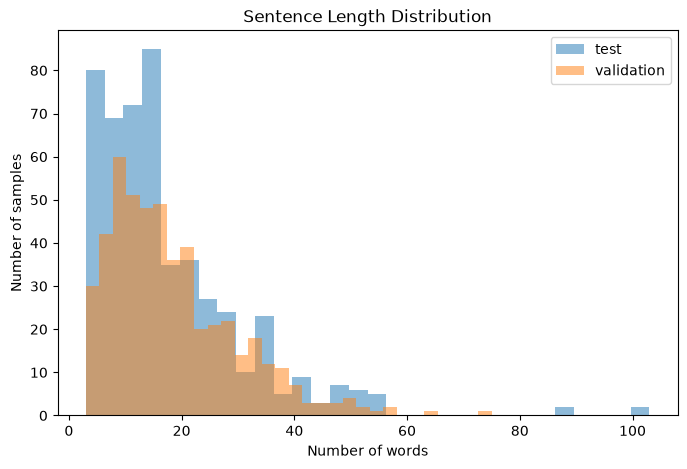

In [37]:
plt.figure(figsize=(8, 5))

for split in df["split"].unique():
    subset = df[df["split"] == split]
    plt.hist(
        subset["text_words"],
        bins=30,
        alpha=0.5,
        label=split
    )

plt.xlabel("Number of words")
plt.ylabel("Number of samples")
plt.title("Sentence Length Distribution")
plt.legend()
plt.show()


### Observations

- The validation and test sets contain 500 samples each.
- The average sentence length is approximately 18 words.
- The longest sentence contains more than 70 words.
- The dataset therefore contains both short and relatively long
  continuous signing sequences.
- This variation makes sequence modeling and text generation more
  challenging than isolated sign recognition.

## 2.4 Kiểm tra keypoint shape

In [38]:
from pathlib import Path
import numpy as np

# Project root
PROJECT_ROOT = Path.cwd()

# Nếu notebook không chạy tại Project root thì tìm manifest
if not (PROJECT_ROOT / "data/processed/manifest.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sample_path = PROJECT_ROOT / df.iloc[0]["npy_path"]

print("Project root:", PROJECT_ROOT)
print("Sample path:", sample_path)
print("File exists:", sample_path.exists())

sequence = np.load(sample_path)

print("Shape:", sequence.shape)
print("Data type:", sequence.dtype)

Project root: d:\2025.3\Project2\Project
Sample path: d:\2025.3\Project2\Project\data\processed\keypoints_bdanko\test_0000.npy
File exists: True
Shape: (256, 225)
Data type: float32


### Input representation

Each frame contains:

- 33 body pose landmarks
- 21 left-hand landmarks
- 21 right-hand landmarks

Each landmark contains `(x, y, z)` coordinates.

Therefore:

`(33 + 21 + 21) × 3 = 225`

features per frame.

The sequence is padded or truncated to a maximum of 256 frames.

# 3. Data Preprocessing & Input Representation

The original landmark representation contains:

Pose + Face + Left Hand + Right Hand

with:

`33 + 468 + 21 + 21 = 543 landmarks`

The project removes face landmarks and keeps:

`33 + 21 + 21 = 75 landmarks`

Each landmark contains 3 coordinates `(x, y, z)`, resulting in:

`75 × 3 = 225 features/frame`.

## Preprocessing pipeline

```
Raw landmark sequence
→ Remove face landmarks
→ Keep pose + two hands
→ Normalize using shoulder center
→ Pad/Truncate to 256 frames
→ Save as `.npy`
→ Feed into the pose encoder
→ GPT-2 decoder generates the target sentence
```

# 4. Training Experiments

## 4.1 Experiment Setup

These experiments were run previously in the Colab/Kaggle environment;
results are reported here from the recorded logs and are not
re-executed in this notebook.

The final experiment used:

- Training samples: 14,000
- Validation samples: 500
- Test samples: 500
- Maximum sequence length: 256 frames
- Epochs: up to 20
- Early stopping patience: 4

```
Epoch 12
train = 1.7411
val   = 1.9382

Early stopping.
Best val loss = 1.9351
```

## 4.2 Experiment Table

In [39]:
experiments = pd.DataFrame({
    "Experiment": [1, 2, 3, 4, 5],
    "Train": [300, 2000, 6000, 12000, 14000],
    "Validation": [60, 200, 400, 400, 500],
    "Test": [60, 200, 400, 400, 500],
    "Best Val Loss": [3.2100, 1.8784, 1.8571, 1.8240, 1.9351],
    "BLEU": [0.48, np.nan, 0.87, 1.67, 1.74],
    "WER": [1.0445, np.nan, 1.2150, 1.0894, 1.0907],
    "Note": [
        "15 epochs",
        "Best at epoch 6",
        "Dataset increased",
        "BLEU increased strongly",
        "MAX_FRAMES: 150 -> 256"
    ]
})

experiments


,Experiment,Train,Validation,Test,Best Val Loss,BLEU,WER,Note
0,1,300,60,60,3.2100,0.48,1.0445,15 epochs
1,2,2000,200,200,1.8784,NaN,NaN,Best at epoch 6
2,3,6000,400,400,1.8571,0.87,1.2150,Dataset increased
3,4,12000,400,400,1.8240,1.67,1.0894,BLEU increased strongly
4,5,14000,500,500,1.9351,1.74,1.0907,MAX_FRAMES: 150 -> 256


## 4.3 Training Analysis

The charts below show how BLEU and WER changed as the training
dataset size increased across the five experiments.

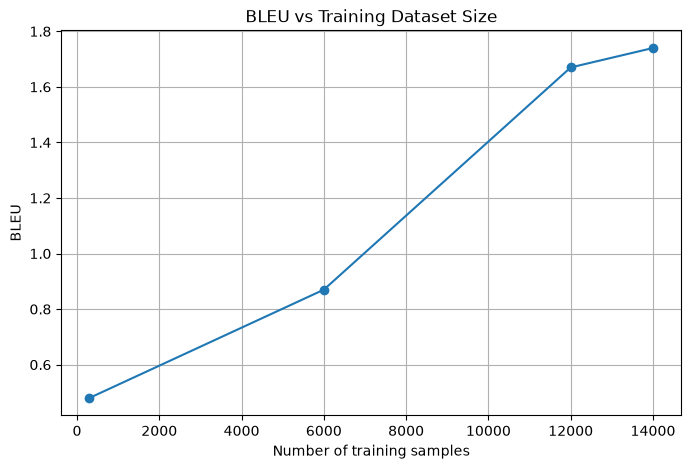

In [40]:
bleu_df = experiments.dropna(subset=["BLEU"])

plt.figure(figsize=(8, 5))

plt.plot(
    bleu_df["Train"],
    bleu_df["BLEU"],
    marker="o"
)

plt.xlabel("Number of training samples")
plt.ylabel("BLEU")
plt.title("BLEU vs Training Dataset Size")
plt.grid(True)
plt.show()


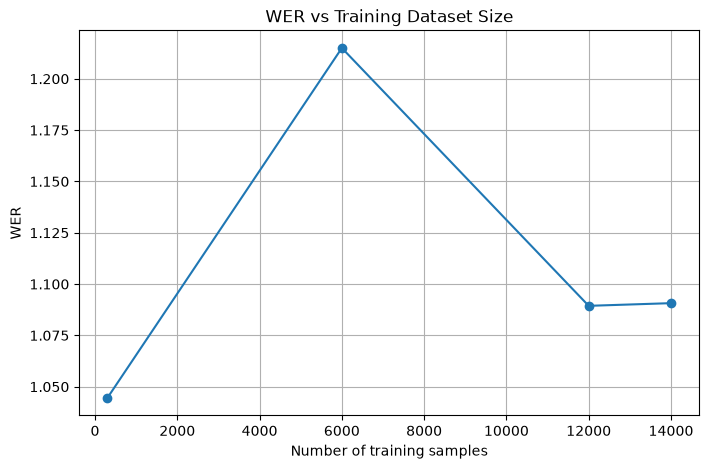

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    bleu_df["Train"],
    bleu_df["WER"],
    marker="o"
)

plt.xlabel("Number of training samples")
plt.ylabel("WER")
plt.title("WER vs Training Dataset Size")
plt.grid(True)
plt.show()


### Observations

Increasing the training set generally improves translation quality.

BLEU increases substantially from 0.48 to 1.74 as the training
set grows from 300 to 14,000 samples.

The relationship between dataset size and WER is less monotonic.
This indicates that increasing the amount of training data does not
automatically guarantee lower word error rate, and model configuration
also affects the final performance.

# 5. Evaluation

The final model (trained on 14,000 samples) is evaluated on the 500
held-out test samples using three complementary metrics: BLEU, WER,
and Semantic Similarity (SIM).

## 5.1 BLEU

In [42]:
predictions = pd.read_csv("../outputs/predictions.csv")

predictions.head()


,Ground Truth,Prediction
0,That's going to act as your tracing pattern fo...,"So, you're going to want to make sure that you..."
1,So you're going to outline your hand all the w...,And then we're going to go ahead and we're jus...
2,So you're going to outline your hand all the w...,"So, if you're going to do this, you want to ma..."
3,Trace it all the way down and then you're goin...,"So, you're going to want to make sure that you..."
4,Trace it all the way down and then you're goin...,"So, you're going to want to make sure that you..."


BLEU measures n-gram overlap between the generated sentence and the
ground-truth reference, capturing how closely the predicted wording
matches the reference sentence.

**Result on the test set: BLEU = 1.74**

## 5.2 WER

WER (Word Error Rate) measures the word-level edit distance
(insertions, deletions, substitutions) required to transform the
predicted sentence into the ground-truth sentence, normalized by the
reference length.

**Result on the test set: WER = 1.0907**

A WER above 1.0 indicates that, on average, the number of word-level
edits needed exceeds the length of the reference sentence itself —
reflecting the difficulty of this continuous translation task at the
current dataset scale.

## 5.3 Semantic Similarity (SIM)

### Mục đích

BLEU và WER chủ yếu đánh giá mức độ trùng khớp về mặt từ/ngữ giữa câu
dự đoán và Ground Truth. Semantic Similarity được bổ sung để đánh giá
mức độ tương đồng về ngữ nghĩa giữa hai câu, ngay cả khi cách diễn đạt
khác nhau.

### Cách tính

Each Ground Truth and Prediction sentence is converted into a sentence
embedding using Sentence-BERT (`all-MiniLM-L6-v2`). The semantic
similarity is then measured using cosine similarity between the two
embeddings:

$$
SIM(GT, Pred) = \frac{E_{GT} \cdot E_{Pred}}{\|E_{GT}\| \, \|E_{Pred}\|}
$$

Trong đó:
- $E_{GT}$: embedding của câu Ground Truth.
- $E_{Pred}$: embedding của câu Prediction.
- SIM càng gần 1 → hai câu càng giống nhau về ngữ nghĩa.
- SIM càng gần 0 → mức tương đồng thấp.

In [43]:
!pip install sentence-transformers

### Kết quả

In [45]:
import numpy as np

gt_embeddings = sbert_model.encode(
    predictions["Ground Truth"].fillna("").tolist(),
    show_progress_bar=True
)

pred_embeddings = sbert_model.encode(
    predictions["Prediction"].fillna("").tolist(),
    show_progress_bar=True
)

predictions["SIM"] = [
    cosine_similarity(
        gt_embeddings[i].reshape(1, -1),
        pred_embeddings[i].reshape(1, -1)
    )[0][0]
    for i in range(len(predictions))
]

print("=== SEMANTIC SIMILARITY ===")
print(f"Mean SIM   : {predictions['SIM'].mean():.4f}")
print(f"Median SIM : {predictions['SIM'].median():.4f}")
print(f"Min SIM    : {predictions['SIM'].min():.4f}")
print(f"Max SIM    : {predictions['SIM'].max():.4f}")

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

=== SEMANTIC SIMILARITY ===
Mean SIM   : 0.1305
Median SIM : 0.1235
Min SIM    : -0.0758
Max SIM    : 0.5376


**Mean SIM** là con số chính nên dùng khi nhận xét tổng quan về khả
năng giữ ngữ nghĩa của model, vì nó ít bị ảnh hưởng bởi các trường hợp
ngoại lệ (outlier) hơn so với Minimum/Maximum SIM.

In [46]:
print(predictions[["Ground Truth", "Prediction", "SIM"]].head(10))

                                        Ground Truth  \
0  That's going to act as your tracing pattern fo...   
1  So you're going to outline your hand all the w...   
2  So you're going to outline your hand all the w...   
3  Trace it all the way down and then you're goin...   
4  Trace it all the way down and then you're goin...   
5  If you have a child and you're doing this for ...   
6  If you have a child and you're doing this for ...   
7  When you cut that out you're going to have eig...   
8  When you cut that out you're going to have eig...   
9  Hi, I'm Les Whitley, cardio vascular training ...   

                                          Prediction       SIM  
0  So, you're going to want to make sure that you...  0.244863  
1  And then we're going to go ahead and we're jus...  0.257184  
2  So, if you're going to do this, you want to ma...  0.130566  
3  So, you're going to want to make sure that you...  0.128679  
4  So, you're going to want to make sure that you...  0.19

In [47]:
print("Number of samples:", len(predictions))
print("Missing SIM:", predictions["SIM"].isna().sum())

Number of samples: 500
Missing SIM: 0


In [48]:
print("=== TOP 5 SIM ===")

top5 = predictions.sort_values("SIM", ascending=False).head(5)

for i, row in top5.iterrows():
    print(f"\nIndex: {i}")
    print("GT  :", row["Ground Truth"])
    print("PRED:", row["Prediction"])
    print(f"SIM : {row['SIM']:.4f}")

=== TOP 5 SIM ===

Index: 99
GT  : We apply that foundation, all over the face.
PRED: So, you're going to want to make sure that you have a good foundation.
SIM : 0.5376

Index: 206
GT  : So what I want you to do is just take your arms out, and we're going to turn the hands all the way down, and then all the way up.
PRED: So, I'm going to take a little bit of my left foot, and I'm just going to lift my right foot up, and that's going to be my left leg.
SIM : 0.4961

Index: 228
GT  : And what you'll do is you start to get real comfortable.
PRED: So, you're going to want to make sure that you have a good foundation.
SIM : 0.3985

Index: 293
GT  : I'm going to do it with a fork.
PRED: I'm going to show you how to do it.
SIM : 0.3698

Index: 291
GT  : I'm going to do it with a fork.
PRED: I'm going to show you how to do it.
SIM : 0.3698


In [49]:
print("=== BOTTOM 5 SIM ===")

bottom5 = predictions.sort_values("SIM", ascending=True).head(5)

for i, row in bottom5.iterrows():
    print(f"\nIndex: {i}")
    print("GT  :", row["Ground Truth"])
    print("PRED:", row["Prediction"])
    print(f"SIM : {row['SIM']:.4f}")

=== BOTTOM 5 SIM ===

Index: 471
GT  : You can see that they have got the wool liners inside of them, probably the warmer of the hand wear that you can get.
PRED: So, you're going to want to make sure that you have the right tools and you're not going to be able to do it on your own.
SIM : -0.0758

Index: 242
GT  : Sometimes Paul gets out of rhythm, so he wants to get back into rhythm.
PRED: So, you're going to want to make sure that you have a good foundation.
SIM : -0.0733

Index: 466
GT  : Generally when it is a spontaneous fight and you don't have gloves you might pick up the snow and pack it and you can generally have a good time but you're not going to be out very long because it gets cold.
PRED: So, I'm going to go ahead and show you how to do that, and then we're going to take a look at how to make it a little bit easier for you.
SIM : -0.0680

Index: 39
GT  : Racers all leave at the same time on the same tree.
PRED: So, you're going to want to make sure that you have a good fo

### Nhận xét: 
Giá trị Mean SIM = 0.1305 cho thấy mức độ tương đồng ngữ nghĩa trung bình giữa câu dự đoán và Ground Truth còn thấp. Tuy nhiên, một số mẫu đạt SIM cao, với giá trị lớn nhất 0.5376, cho thấy model vẫn có khả năng tạo ra câu có nội dung tương đối liên quan trong một số trường hợp. Các giá trị SIM âm thể hiện những trường hợp prediction có mức tương đồng ngữ nghĩa rất thấp với Ground Truth.

# 6. Conclusion

## Main findings

1. The dataset contains continuous signing sequences with variable
   sentence lengths, making the task more challenging than isolated
   sign recognition.

2. The input representation uses 75 landmarks per frame:
   33 pose + 21 left-hand + 21 right-hand landmarks.

3. Removing face landmarks reduces the input dimensionality to
   225 features per frame.

4. Increasing the training dataset from 300 to 14,000 samples
   substantially improves BLEU from 0.48 to 1.74.

5. The final experiment with 14,000 training samples achieved:
   - BLEU: 1.74
   - WER: 1.0907
   - Best validation loss: 1.9351

6. Semantic Similarity (SIM) provides a complementary view: even when
   lexical overlap (BLEU) is low and WER is high, the mean SIM score
   indicates that the model retains a meaningful degree of semantic
   alignment with the reference sentences in many cases.

7. Despite the improvement, the qualitative results show that
   generated sentences can differ considerably from the reference
   translations, both lexically and, in some cases, semantically.

## Limitations

- The current experiment uses a relatively limited subset of the
  available dataset.
- WER remains high, indicating significant word-level differences
  between generated and reference sentences.
- The model may generate fluent but semantically different sentences.

## Future improvements

Potential improvements include:
- using more training data,
- improving temporal sequence encoding,
- tuning the decoder and generation strategy,
- improving alignment between visual features and language,
- and evaluating additional translation metrics.